# Spatial Autocorrelation Analysis

This notebook performs spatial autocorrelation analysis to detect clustering patterns in power plant capacity factors across geographic space.

## Objectives
- Compute Global Moran's I statistic
- Test for spatial autocorrelation significance
- Visualize spatial patterns
- Identify local clusters (LISA)

In [16]:
import sys
from pathlib import Path

# Add parent directory to path
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
import seaborn as sns

from src.preprocessing import Preprocessor
from src.feature_engineering import FeatureEngineer
from src.spatial_analysis import SpatialAnalyzer

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

%matplotlib inline

## 1. Load and Prepare Data

In [17]:
preprocessor = Preprocessor()
data_path = Path.cwd().parent / 'data' / 'raw' / 'global_power_plant_database.csv'

df = preprocessor.load_data(data_path)
df = preprocessor.clean_data(df)
df = preprocessor.filter_valid_generation(df)

engineer = FeatureEngineer()
df = engineer.engineer_all_features(df)

print(f"Prepared dataset: {len(df):,} plants")
print(f"Mean capacity factor: {df['capacity_factor'].mean():.3f}")

2026-03-10 11:26:55,444 - INFO - Loading data from e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\data\raw\global_power_plant_database.csv
2026-03-10 11:26:56,157 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:26:56,161 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:26:56,157 - INFO - Dataset loaded: 34936 rows, 36 columns
2026-03-10 11:26:56,161 - INFO - Starting data cleaning. Initial rows: 34936
2026-03-10 11:26:56,324 - INFO - Duplicates removed: 0 rows
2026-03-10 11:26:56,335 - INFO - Rows after removing missing critical columns: 34936
2026-03-10 11:26:56,324 - INFO - Duplicates removed: 0 rows
2026-03-10 11:26:56,335 - INFO - Rows after removing missing critical columns: 34936
2026-03-10 11:26:56,342 - INFO - Data cleaning completed. Final rows: 34936
2026-03-10 11:26:56,345 - INFO - Total rows removed: 0
2026-03-10 11:26:56,349 - INFO - Filtering valid generation data. Initial rows: 34936
2026-03-

Prepared dataset: 33,045 plants
Mean capacity factor: 0.305


## 2. Global Moran's I Analysis

In [18]:
spatial_analyzer = SpatialAnalyzer()

moran_result = spatial_analyzer.compute_morans_i(df, 'capacity_factor')

print("\n" + "="*60)
print("GLOBAL MORAN'S I RESULTS")
print("="*60)
print(f"Moran's I: {moran_result['moran_i']:.4f}")
print(f"p-value: {moran_result['p_value']:.6f}")
print(f"z-score: {moran_result['z_score']:.4f}")
print("="*60)

if moran_result['p_value'] < 0.05:
    if moran_result['moran_i'] > 0:
        print("\nInterpretation: Significant POSITIVE spatial autocorrelation detected.")
        print("High capacity factor plants tend to cluster near other high CF plants.")
    else:
        print("\nInterpretation: Significant NEGATIVE spatial autocorrelation detected.")
        print("High capacity factor plants tend to be near low CF plants.")
else:
    print("\nInterpretation: No significant spatial autocorrelation (random distribution).")

2026-03-10 11:29:06,233 - INFO - Computing Moran's I for capacity_factor
2026-03-10 11:29:06,286 - INFO - Building KNN spatial weights (k=8)
2026-03-10 11:29:06,286 - INFO - Building KNN spatial weights (k=8)
2026-03-10 11:29:09,080 - INFO - Spatial weights computed with 40 disconnected components (expected for isolated plants)
2026-03-10 11:29:09,080 - INFO - Spatial weights computed with 40 disconnected components (expected for isolated plants)
2026-03-10 11:29:12,528 - INFO - Moran's I: 0.3865
2026-03-10 11:29:12,530 - INFO - p-value: 0.0010
2026-03-10 11:29:12,531 - INFO - z-score: 148.0488
2026-03-10 11:29:12,528 - INFO - Moran's I: 0.3865
2026-03-10 11:29:12,530 - INFO - p-value: 0.0010
2026-03-10 11:29:12,531 - INFO - z-score: 148.0488



GLOBAL MORAN'S I RESULTS
Moran's I: 0.3865
p-value: 0.001000
z-score: 148.0488

Interpretation: Significant POSITIVE spatial autocorrelation detected.
High capacity factor plants tend to cluster near other high CF plants.


2026-03-10 11:29:17,112 - INFO - Creating Moran scatter plot for capacity_factor
2026-03-10 11:29:24,266 - INFO - Moran scatter plot saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\morans_i_scatter_notebook.png
2026-03-10 11:29:24,266 - INFO - Moran scatter plot saved to e:\Geospatial Machine Learning for Global Power Plant Efficiency and Infrastructure Inequality\figures\morans_i_scatter_notebook.png


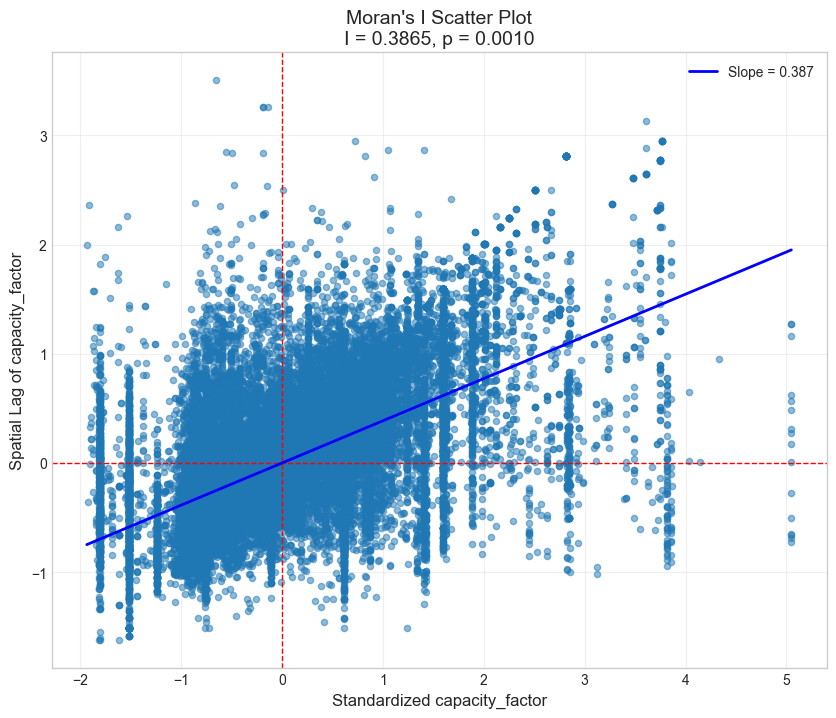

In [19]:
figures_dir = Path.cwd().parent / 'figures'
spatial_analyzer.plot_morans_scatter(moran_result, 'capacity_factor', 
                                     figures_dir / 'morans_i_scatter_notebook.png')

## 3. Local Indicators of Spatial Association (LISA)

In [20]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

weights = KNN.from_dataframe(gdf, k=8)

lisa = Moran_Local(gdf['capacity_factor'], weights)

gdf['lisa_cluster'] = lisa.q
gdf['lisa_pvalue'] = lisa.p_sim
gdf['lisa_significant'] = (gdf['lisa_pvalue'] < 0.05).astype(int)

print("\nLISA Cluster Types:")
print("1 = High-High (hotspot)")
print("2 = Low-High")
print("3 = Low-Low (coldspot)")
print("4 = High-Low")
print("\nCluster counts:")
print(gdf['lisa_cluster'].value_counts().sort_index())

c:\Python312\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 40 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)



LISA Cluster Types:
1 = High-High (hotspot)
2 = Low-High
3 = Low-Low (coldspot)
4 = High-Low

Cluster counts:
lisa_cluster
1    10232
2     4237
3    14945
4     3631
Name: count, dtype: int64


In [21]:
significant_clusters = gdf[gdf['lisa_significant'] == 1]
print(f"\nSignificant clusters (p < 0.05): {len(significant_clusters):,} plants ({len(significant_clusters)/len(gdf)*100:.1f}%)")
print("\nSignificant cluster type distribution:")
print(significant_clusters['lisa_cluster'].value_counts().sort_index())


Significant clusters (p < 0.05): 14,737 plants (44.6%)

Significant cluster type distribution:
lisa_cluster
1    5074
2    1091
3    7677
4     895
Name: count, dtype: int64


## 4. LISA Cluster Map

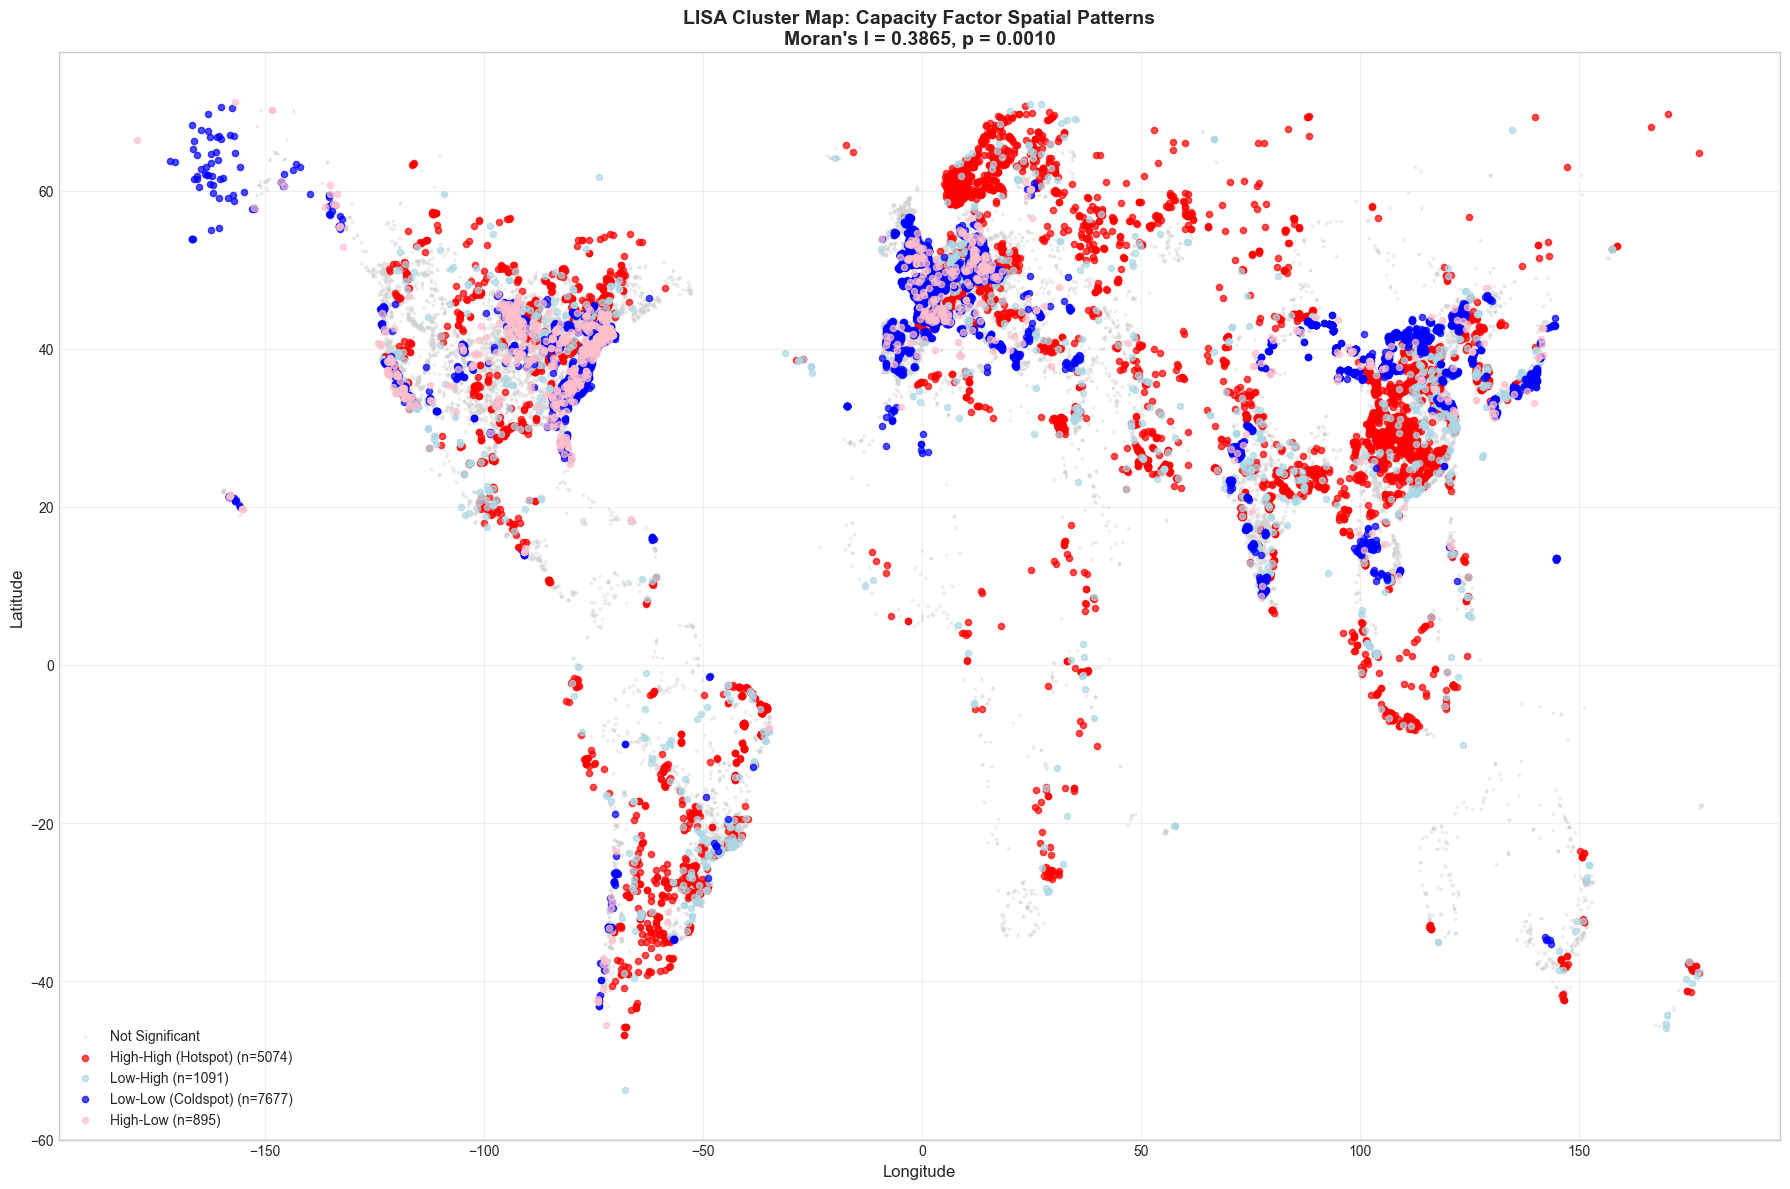

In [22]:
fig, ax = plt.subplots(figsize=(18, 12))

non_sig = gdf[gdf['lisa_significant'] == 0]
ax.scatter(non_sig['longitude'], non_sig['latitude'], 
          c='lightgray', s=3, alpha=0.3, label='Not Significant')

colors = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink'}
labels = {1: 'High-High (Hotspot)', 2: 'Low-High', 3: 'Low-Low (Coldspot)', 4: 'High-Low'}

for cluster_type in [1, 2, 3, 4]:
    cluster_data = significant_clusters[significant_clusters['lisa_cluster'] == cluster_type]
    if len(cluster_data) > 0:
        ax.scatter(cluster_data['longitude'], cluster_data['latitude'],
                  c=colors[cluster_type], s=20, alpha=0.7, 
                  label=f"{labels[cluster_type]} (n={len(cluster_data)})")

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f"LISA Cluster Map: Capacity Factor Spatial Patterns\nMoran's I = {moran_result['moran_i']:.4f}, p = {moran_result['p_value']:.4f}", 
            fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'lisa_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Regional Analysis

In [23]:
regional_stats = spatial_analyzer.compute_regional_stats(df)
print("\nRegional Statistics:")
print(regional_stats)

2026-03-10 11:30:08,356 - INFO - Computing regional statistics
2026-03-10 11:30:08,417 - INFO - Regional statistics computed for 7 continents
2026-03-10 11:30:08,417 - INFO - Regional statistics computed for 7 continents



Regional Statistics:
               mean_capacity_factor  total_capacity_mw  renewable_share
continent                                                              
Asia                          0.343        2684695.574            0.222
North America                 0.286        1415169.760            0.266
Europe                        0.273        1037680.400            0.305
South America                 0.368         255931.753            0.686
Africa                        0.385         155424.033            0.257
Oceania                       0.344          72132.540            0.337
Unknown                       0.401            599.000            1.000


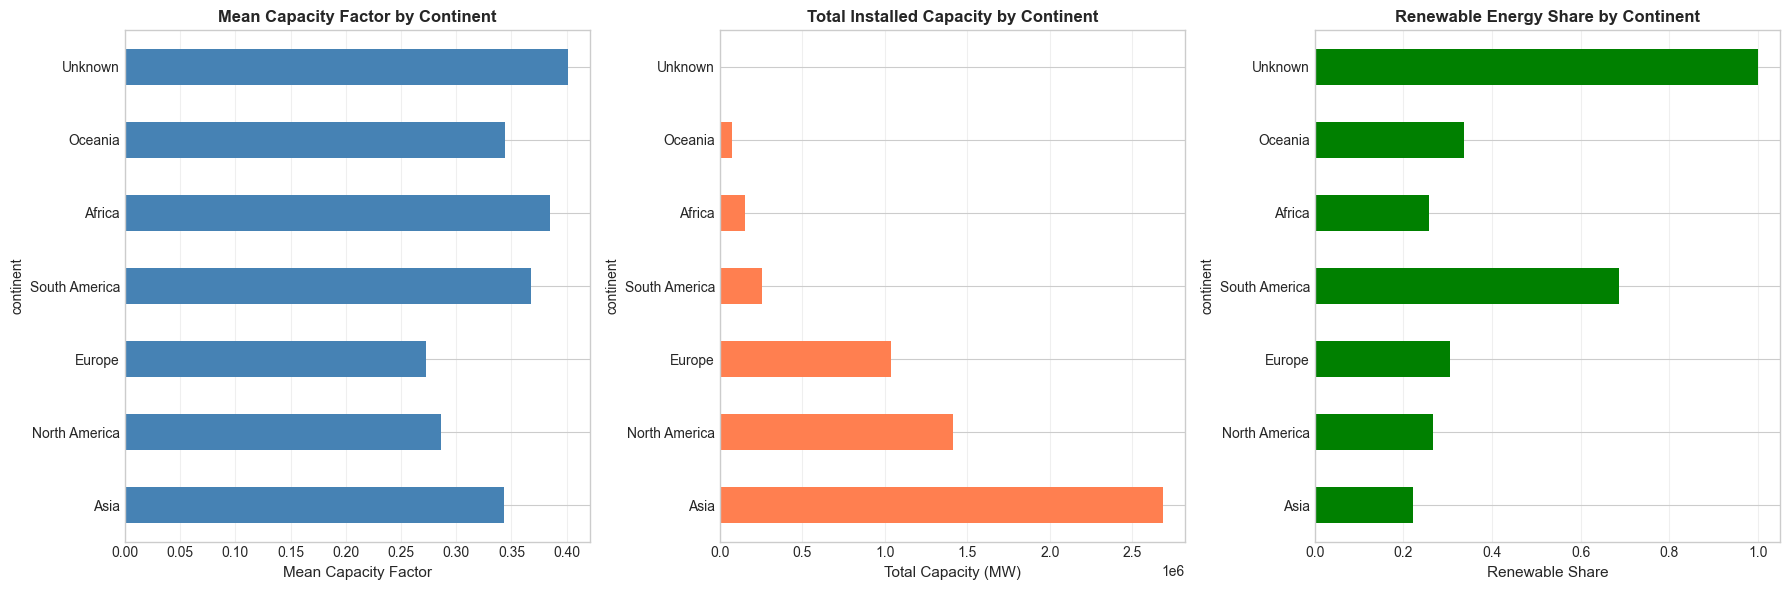

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

regional_stats['mean_capacity_factor'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Mean Capacity Factor', fontsize=11)
axes[0].set_title('Mean Capacity Factor by Continent', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

regional_stats['total_capacity_mw'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('Total Capacity (MW)', fontsize=11)
axes[1].set_title('Total Installed Capacity by Continent', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

regional_stats['renewable_share'].plot(kind='barh', ax=axes[2], color='green')
axes[2].set_xlabel('Renewable Share', fontsize=11)
axes[2].set_title('Renewable Energy Share by Continent', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(figures_dir / 'regional_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Spatial Autocorrelation by Fuel Type

In [25]:
top_fuels = df['primary_fuel'].value_counts().head(6).index

moran_by_fuel = []

for fuel in top_fuels:
    df_fuel = df[df['primary_fuel'] == fuel]
    if len(df_fuel) > 50:
        try:
            analyzer_fuel = SpatialAnalyzer()
            result = analyzer_fuel.compute_morans_i(df_fuel, 'capacity_factor')
            moran_by_fuel.append({
                'Fuel Type': fuel,
                'Moran I': result['moran_i'],
                'p-value': result['p_value'],
                'z-score': result['z_score'],
                'Sample Size': len(df_fuel)
            })
        except:
            print(f"Could not compute Moran's I for {fuel}")

moran_fuel_df = pd.DataFrame(moran_by_fuel)
print("\nMoran's I by Fuel Type:")
print(moran_fuel_df.to_string(index=False))

2026-03-10 11:30:44,823 - INFO - Computing Moran's I for capacity_factor
2026-03-10 11:30:44,857 - INFO - Building KNN spatial weights (k=8)
2026-03-10 11:30:44,857 - INFO - Building KNN spatial weights (k=8)
2026-03-10 11:30:45,974 - INFO - Spatial weights computed with 27 disconnected components (expected for isolated plants)
2026-03-10 11:30:45,974 - INFO - Spatial weights computed with 27 disconnected components (expected for isolated plants)
2026-03-10 11:30:47,740 - INFO - Moran's I: 0.7358
2026-03-10 11:30:47,743 - INFO - p-value: 0.0010
2026-03-10 11:30:47,740 - INFO - Moran's I: 0.7358
2026-03-10 11:30:47,743 - INFO - p-value: 0.0010
2026-03-10 11:30:47,746 - INFO - z-score: 163.4179
2026-03-10 11:30:47,746 - INFO - z-score: 163.4179
2026-03-10 11:30:47,783 - INFO - Computing Moran's I for capacity_factor
2026-03-10 11:30:47,807 - INFO - Building KNN spatial weights (k=8)
2026-03-10 11:30:47,783 - INFO - Computing Moran's I for capacity_factor
2026-03-10 11:30:47,807 - INFO - 


Moran's I by Fuel Type:
Fuel Type  Moran I  p-value    z-score  Sample Size
    Solar 0.735842    0.001 163.417916        10665
    Hydro 0.564039    0.001 101.365828         7156
     Wind 0.801924    0.001 125.621128         5343
      Gas 0.837353    0.001 114.562999         3939
     Coal 0.787036    0.001  80.730299         2305
      Oil 0.885956    0.001  90.154977         2258


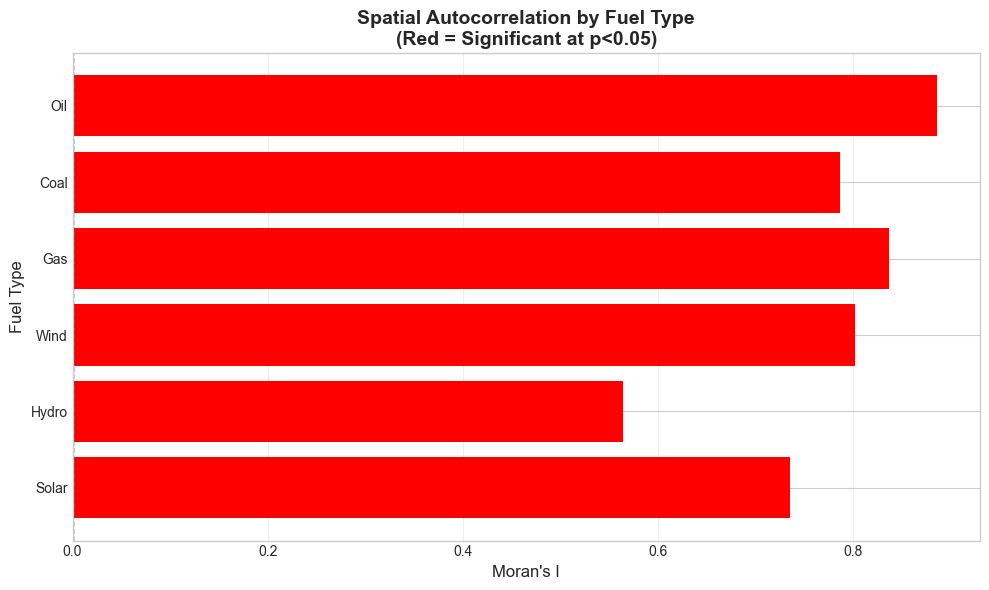

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_sig = ['red' if p < 0.05 else 'gray' for p in moran_fuel_df['p-value']]
bars = ax.barh(moran_fuel_df['Fuel Type'], moran_fuel_df['Moran I'], color=colors_sig)

ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel("Moran's I", fontsize=12)
ax.set_ylabel('Fuel Type', fontsize=12)
ax.set_title("Spatial Autocorrelation by Fuel Type\n(Red = Significant at p<0.05)", 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(figures_dir / 'morans_i_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distance-Based Analysis

In [27]:
sample_size = min(5000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

gdf_sample = gpd.GeoDataFrame(
    df_sample,
    geometry=gpd.points_from_xy(df_sample['longitude'], df_sample['latitude']),
    crs='EPSG:4326'
)

k_values = [4, 8, 12, 16, 20]
moran_by_k = []

for k in k_values:
    weights_k = KNN.from_dataframe(gdf_sample, k=k)
    moran_k = Moran(gdf_sample['capacity_factor'], weights_k)
    moran_by_k.append({
        'k': k,
        'Moran I': moran_k.I,
        'p-value': moran_k.p_sim
    })

moran_k_df = pd.DataFrame(moran_by_k)
print("\nMoran's I by number of nearest neighbors (k):")
print(moran_k_df)

c:\Python312\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 33 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Python312\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Python312\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Python312\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Python312\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconne


Moran's I by number of nearest neighbors (k):
    k   Moran I  p-value
0   4  0.301099    0.001
1   8  0.265607    0.001
2  12  0.250129    0.001
3  16  0.236997    0.001
4  20  0.228121    0.001


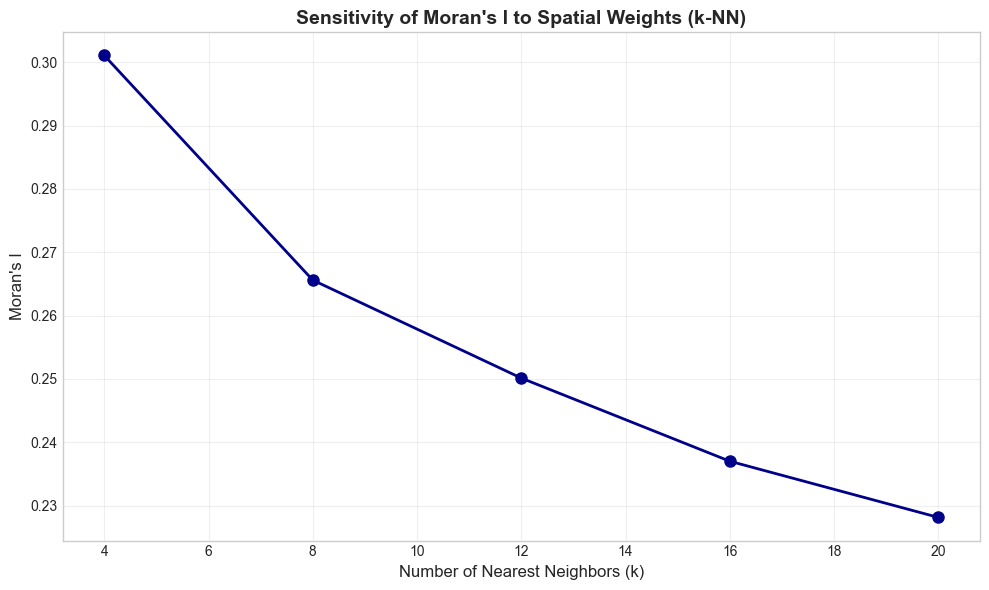

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(moran_k_df['k'], moran_k_df['Moran I'], marker='o', linewidth=2, markersize=8, color='darkblue')
ax.set_xlabel('Number of Nearest Neighbors (k)', fontsize=12)
ax.set_ylabel("Moran's I", fontsize=12)
ax.set_title("Sensitivity of Moran's I to Spatial Weights (k-NN)", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'morans_i_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Key findings from spatial autocorrelation analysis:

1. **Global Pattern**: Moran's I indicates the degree of spatial clustering in capacity factors
2. **Statistical Significance**: p-value determines whether clustering is beyond random chance
3. **Local Clusters**: LISA analysis identifies specific geographic hotspots and coldspots
4. **Regional Variation**: Different continents show distinct capacity factor patterns
5. **Fuel-Specific Patterns**: Spatial autocorrelation varies by generation technology
6. **Scale Sensitivity**: Moran's I changes with spatial scale (k-neighbors)

These spatial patterns inform clustering algorithms and regional modeling strategies.